##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from svipy.normflow import scalarConditionedNetworkCNN, identityTimeEmbedding, fourierTimeEmbedding, timeConditionedField, continuousNormFlow
from svipy.diffusion import linearConditionalPath, varPreservingConditionalPathTrigonometric, conditionalFlowMatcher
from svipy.diffusion import reversedConditionalPath, varPreservingConditionalPathTrigonometric, varPreservingConditionalPathDDPMCosine
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


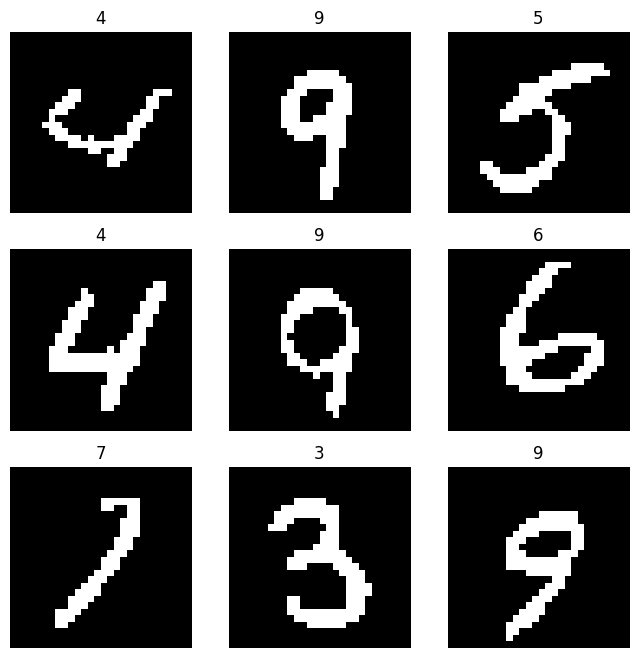

In [4]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


##### Conditional Flow Matching

###### Optimal transport paths

In [12]:
tcn = scalarConditionedNetworkCNN(1, [(32, 5), (32, 5), (32, 5), (32, 5), (32, 5), (32, 5)], t_dim=1) 
embed = identityTimeEmbedding()
tcf = timeConditionedField(tcn, embed)

path = linearConditionalPath()

model_cfm_ot = conditionalFlowMatcher(path, tcf).to(device)

In [13]:
learning_rate = 0.001
batch_size = 128
epochs = 200

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_cfm_ot.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [14]:
%%time 
model_cfm_ot.trainLoop(trainLoader, optimizer, epochs, 
                       reportIters=100, scheduler=None,
                       checkpointPath='../checkpoints/mnist_cfm/',
                       checkPointName='cfm_ot',
                       validDataLoader=validLoader,
                       earlyStopper=stopper
                      )

Epoch 1
-------------------------------
totalLoss: 267.070648[12800/60000]
totalLoss: 177.193970[25600/60000]
totalLoss: 166.377228[38400/60000]
totalLoss: 147.132751[51200/60000]
Validation Error: 140.942131
Epoch 2
-------------------------------
totalLoss: 138.905762[12800/60000]
totalLoss: 131.993362[25600/60000]
totalLoss: 133.422684[38400/60000]
totalLoss: 130.500351[51200/60000]
Validation Error: 112.745744
Epoch 3
-------------------------------
totalLoss: 119.158607[12800/60000]
totalLoss: 120.395683[25600/60000]
totalLoss: 111.714462[38400/60000]
totalLoss: 100.843102[51200/60000]
Validation Error: 114.911750
Epoch 4
-------------------------------
totalLoss: 98.983795[12800/60000]
totalLoss: 99.108269[25600/60000]
totalLoss: 94.368706[38400/60000]
totalLoss: 105.358124[51200/60000]
Validation Error: 98.768110
Epoch 5
-------------------------------
totalLoss: 98.928467[12800/60000]
totalLoss: 102.065681[25600/60000]
totalLoss: 98.113594[38400/60000]
totalLoss: 103.136261[512

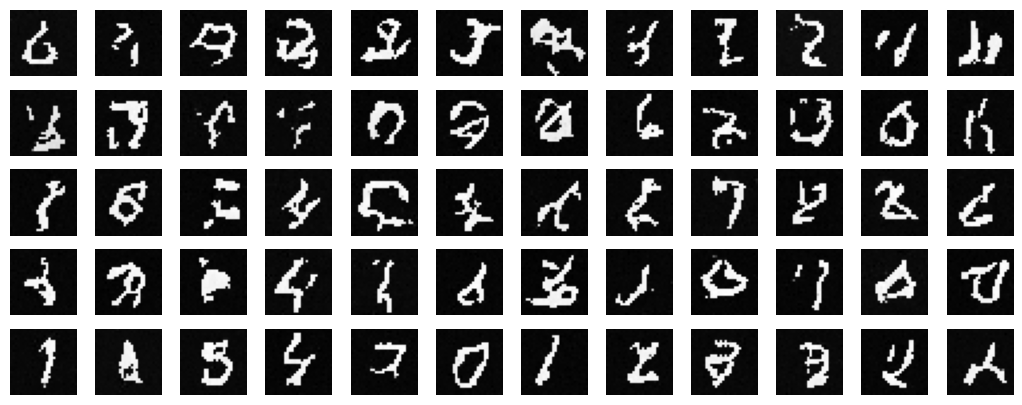

In [15]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = continuousNormFlow(tcf)

idxs = []

with torch.no_grad():
    for i in range(nCols * nRows):
        x0 = torch.randn([1, 1, 28, 28]).to(device)
        
        img = cnf.generate(x0)[0].cpu().detach()
        img = img.numpy().squeeze()
        
        figure.add_subplot(nRows, nCols, i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')

plt.show()

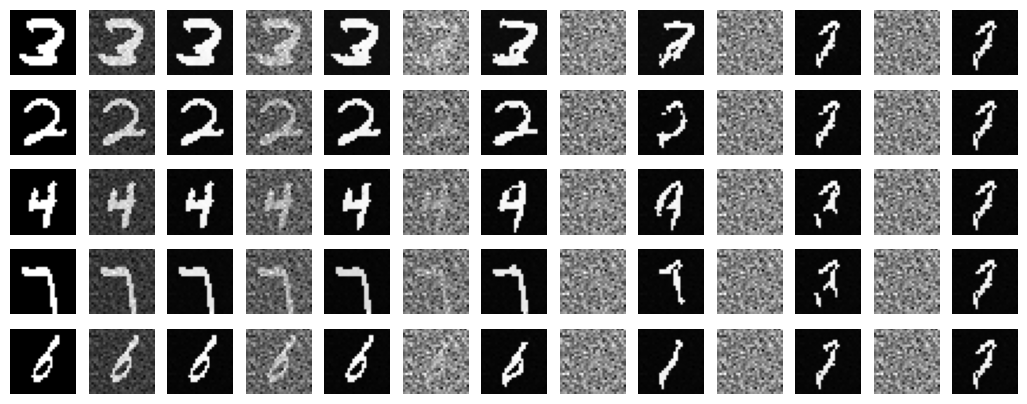

In [16]:
nCols = 13
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = continuousNormFlow(tcf).to(device)

idxs = []
tx = [0.9, 0.75, 0.5, 0.25, 0.1, 0.0]

sidx = torch.randint(len(trainData), size=(1,)).item()
x1, _ = trainData[sidx]
x0 = torch.randn_like(x1).to(device)  # sample a single noise image

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        x1, label = trainData[sidx]

        # original image
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(x1.squeeze(), cmap='gray')

        x1 = x1.unsqueeze(0).to(device)        
        for j, txj in enumerate(tx):
            # interpolated
            xt, _ = path(x0, x1, torch.tensor([txj]).to(device))
            img = xt.cpu().detach().numpy().squeeze()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 2)
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap='gray')

            # generated
            img = cnf.interpolate(xt, txj, 1.)[0].cpu().detach()
            img = img.numpy().squeeze()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 3)
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap='gray')

plt.show()

###### VAR preserving paths

In [17]:
tcn = scalarConditionedNetworkCNN(1, [(32, 5), (32, 5), (32, 5), (32, 5), (32, 5), (32, 5)], t_dim=8) 
embed = fourierTimeEmbedding(8)
tcf = timeConditionedField(tcn, embed)

path = reversedConditionalPath(varPreservingConditionalPathTrigonometric())

model_cfm_varp = conditionalFlowMatcher(path, tcf).to(device)

In [18]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_cfm_varp.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=10, minDelta=0.1, mode='min', restoreBestWeights=True)

In [19]:
%%time 
model_cfm_varp.trainLoop(trainLoader, optimizer, epochs, 
                         reportIters=100, scheduler=None,
                         checkpointPath='../checkpoints/mnist_cfm/',
                         checkPointName='cfm_varp',
                         validDataLoader=validLoader,
                         earlyStopper=stopper
                        )

Epoch 1
-------------------------------
totalLoss: 482.309387[12800/60000]
totalLoss: 299.089233[25600/60000]
totalLoss: 268.866425[38400/60000]
totalLoss: 240.492630[51200/60000]
Validation Error: 231.473881
Epoch 2
-------------------------------
totalLoss: 214.886414[12800/60000]
totalLoss: 180.966644[25600/60000]
totalLoss: 188.810150[38400/60000]
totalLoss: 188.764740[51200/60000]
Validation Error: 184.502246
Epoch 3
-------------------------------
totalLoss: 172.660797[12800/60000]
totalLoss: 167.579071[25600/60000]
totalLoss: 172.723389[38400/60000]
totalLoss: 165.646393[51200/60000]
Validation Error: 170.081621
Epoch 4
-------------------------------
totalLoss: 156.899597[12800/60000]
totalLoss: 174.062378[25600/60000]
totalLoss: 173.829941[38400/60000]
totalLoss: 156.059265[51200/60000]
Validation Error: 156.749588
Epoch 5
-------------------------------
totalLoss: 142.470764[12800/60000]
totalLoss: 163.976868[25600/60000]
totalLoss: 165.387375[38400/60000]
totalLoss: 148.6060

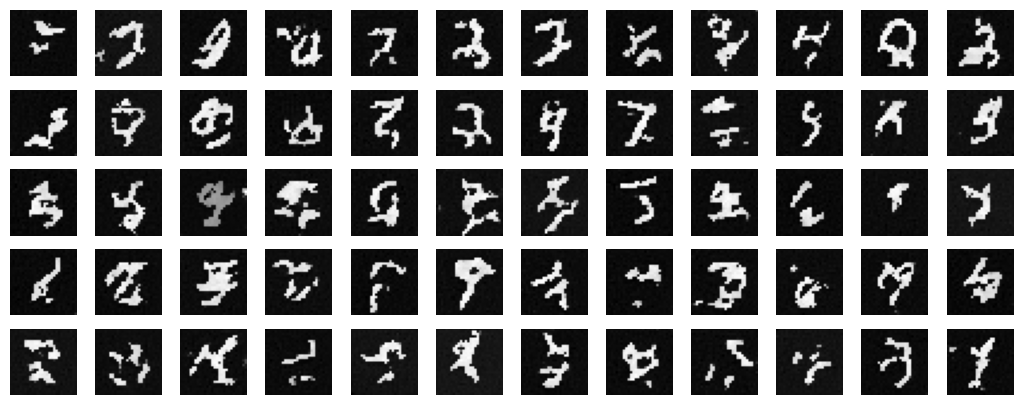

In [20]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = continuousNormFlow(tcf)

idxs = []

with torch.no_grad():
    for i in range(nCols * nRows):
        x0 = torch.randn([1, 1, 28, 28]).to(device)
        
        img = cnf.generate(x0)[0].cpu().detach()
        img = img.numpy().squeeze()
        
        figure.add_subplot(nRows, nCols, i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')

plt.show()

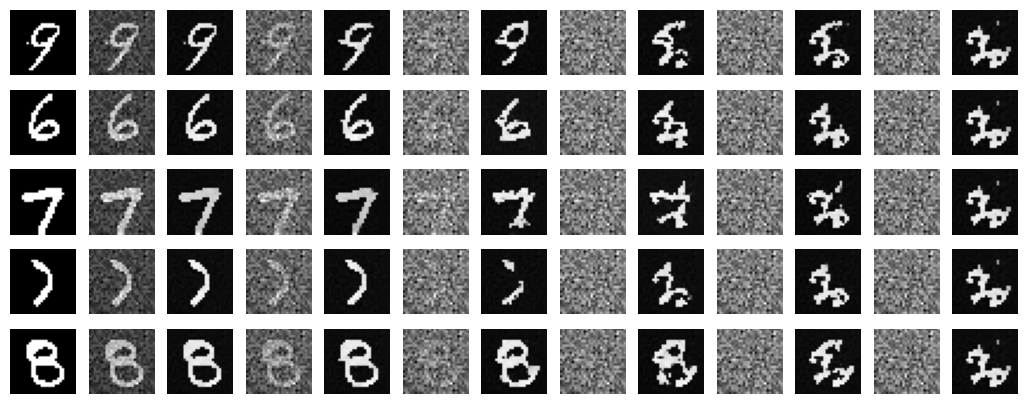

In [21]:
nCols = 13
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = continuousNormFlow(tcf).to(device)

idxs = []
tx = [0.9, 0.75, 0.5, 0.25, 0.1, 0.0]

sidx = torch.randint(len(trainData), size=(1,)).item()
x1, _ = trainData[sidx]
x0 = torch.randn_like(x1).to(device)  # sample a single noise image

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        x1, label = trainData[sidx]

        # original image
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(x1.squeeze(), cmap='gray')

        x1 = x1.unsqueeze(0).to(device)        
        for j, txj in enumerate(tx):
            # interpolated
            xt, _ = path(x0, x1, torch.tensor([txj]).to(device))
            img = xt.cpu().detach().numpy().squeeze()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 2)
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap='gray')

            # generated
            img = cnf.interpolate(xt, txj, 1.)[0].cpu().detach()
            img = img.numpy().squeeze()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 3)
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap='gray')

plt.show()